# โครงการสร้างข้อมูล PV Load Profile (8760 ชั่วโมง)
ในสคริปต์นี้เราจะสร้างข้อมูลการใช้ไฟฟ้ารายชั่วโมงตลอด 1 ปี โดยปรับค่าให้ตรงกับเป้าหมายรายเดือน

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pvlib
from pvlib import iotools
from pvlib.location import Location
from pvlib.pvsystem import PVSystem
from pvlib.modelchain import ModelChain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

# ตั้งค่าฟอนต์ให้รองรับภาษาไทย (ใช้ Tahoma ซึ่งติดมากับ Windows ทุกเครื่อง)
# matplotlib.rcParams['font.family'] = 'Tahoma'
matplotlib.rcParams['font.family'] = 'Arundina Sans Mono'
matplotlib.rcParams['axes.unicode_minus'] = False  # แก้ปัญหาเครื่องหมายลบแสดงผิด

# ส่วนที่ 1: กำหนดข้อมูลตั้งต้น (Input Data)

In [53]:
# โหลดข้อมูลการใช้ไฟฟ้ารายวันแบบไม่สม่ำเสมอ (เวลา, กิโลวัตต์) จากไฟล์ Excel (แยกตามชีต)
# คุณสามารถเข้าไปตั้งค่าข้อมูลทั้งหมดได้ที่ไฟล์ Inputs.xlsx ที่เดียว
weekday_raw = pd.read_excel('Inputs.xlsx', sheet_name='Weekday')
weekend_raw = pd.read_excel('Inputs.xlsx', sheet_name='Weekend')

# แปลงเวลา (Time) ให้เป็นรูปแบบ datetime เพื่อใช้ในการคำนวณ (ใช้วันสมมติ 2000-01-01 เป็นตัวแทน)
# แปลงเป็น string ก่อนเผื่อ Pandas ดึงข้อมูลมาจาก Excel เป็นรูปแบบ Time Object
weekday_raw['Time'] = pd.to_datetime('2000-01-01 ' + weekday_raw['Time'].astype(str))
weekend_raw['Time'] = pd.to_datetime('2000-01-01 ' + weekend_raw['Time'].astype(str))

# โหลดข้อมูลเป้าหมายรายเดือนที่ต้องการ (kWh) จากไฟล์ Excel ชีต Targets
df_targets = pd.read_excel('Inputs.xlsx', sheet_name='Targets')

# แปลงตาราง (DataFrame) ให้กลับเป็น Dictionary {Month: Target_kWh} 
# เพื่อให้โค้ดส่วนที่ 4 (Scaling) ยังคงนำไปใช้งานต่อได้ทันทีโดยไม่ต้องแก้โค้ดเพิ่มเติม
monthly_targets = dict(zip(df_targets['Month'], df_targets['Target_kWh']))

print(type(weekday_raw))

<class 'pandas.core.frame.DataFrame'>


C:\Users\DadDesk\AppData\Local\Temp\ipykernel_28400\370472779.py:8: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  weekday_raw['Time'] = pd.to_datetime('2000-01-01 ' + weekday_raw['Time'].astype(str), infer_datetime_format=True)
C:\Users\DadDesk\AppData\Local\Temp\ipykernel_28400\370472779.py:9: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  weekend_raw['Time'] = pd.to_datetime('2000-01-01 ' + weekend_raw['Time'].astype(str), infer_datetime_format=True)


# ส่วนที่ 2: การแปลงข้อมูลให้เป็นรายชั่วโมง (Interpolation)

In [54]:
# สร้างฟังก์ชันเพื่อใช้ซ้ำ
def interpolate_to_hourly(df_raw):
    # ---- การแก้ไขปัญหาข้อมูลจริง ----
    # ขั้นที่ 1: เรียงข้อมูลตามเวลาจากน้อยไปมาก (จำเป็นมาก! ข้อมูลจริงมักไม่เรียง)
    df_raw = df_raw.sort_values('Time').reset_index(drop=True)
    
    # ขั้นที่ 2: เพิ่มจุดยึด (Anchor Points) ที่ 00:00 และ 23:59 ถ้ายังไม่มี
    # เพื่อให้ Interpolation ครอบคลุมตลอด 24 ชั่วโมง
    # ใช้ค่าเฉลี่ยจากจุดปลายๆ 2 จุด (ไม่ได้สมมติค่าสุ่ม)
    t_start = pd.Timestamp('2000-01-01 00:00')
    t_end   = pd.Timestamp('2000-01-01 23:59')
    
    if df_raw['Time'].min() > t_start:
        # ไม่มีจุดก่อน 00:00 → ยืมค่าจากจุดข้อมูลแรกสุด (ต่อเส้นราบ)
        val_start = df_raw.loc[df_raw['Time'].idxmin(), 'Load_kW']
        row_start = pd.DataFrame({'Time': [t_start], 'Load_kW': [val_start]})
        df_raw = pd.concat([row_start, df_raw], ignore_index=True)
    
    if df_raw['Time'].max() < t_end:
        # ไม่มีจุดหลัง 23:59 → ยืมค่าจากจุดข้อมูลท้ายสุด (ต่อเส้นราบ)
        val_end = df_raw.loc[df_raw['Time'].idxmax(), 'Load_kW']
        row_end = pd.DataFrame({'Time': [t_end], 'Load_kW': [val_end]})
        df_raw = pd.concat([df_raw, row_end], ignore_index=True)
    
    # ---- ส่วน Interpolation เดิม (เหมือนเดิม) ----
    df_raw = df_raw.set_index('Time')
    
    # สร้าง index ราย 1 ชั่วโมงตั้งแต่ 00:00 ถึง 23:00 ของวันสมมติ
    hourly_index = pd.date_range(start='2000-01-01 00:00', end='2000-01-01 23:00', freq='h')
    
    # รวม index ของข้อมูลดิบกับ hourly_index เข้าด้วยกัน
    combined_index = df_raw.index.union(hourly_index).sort_values()
    df_combined = df_raw.reindex(combined_index)
    
    # ทำ Linear Interpolation (เติมค่าว่างด้วยการเทียบบัญญัติไตรยางศ์ตามเวลา)
    df_interp = df_combined.interpolate(method='time')
    
    # ดึงมาเฉพาะรายชั่วโมงที่เราต้องการเป๊ะๆ
    df_hourly = df_interp.loc[hourly_index].copy()
    
    # ดึงเฉพาะเวลา (HH:MM:SS) ออกมาเพื่อนำไปจับคู่กับวันที่จริงภายหลัง
    df_hourly.index = df_hourly.index.time
    return df_hourly['Load_kW']

# ใช้งานฟังก์ชัน
hourly_weekday = interpolate_to_hourly(weekday_raw)
hourly_weekend = interpolate_to_hourly(weekend_raw)

print("ตัวอย่างข้อมูล Weekday รายชั่วโมง (ที่ผ่านการ Interpolate แล้ว):")
print(hourly_weekday)
print(f"\nจำนวนชั่วโมงต่อวัน: {len(hourly_weekday)} ชั่วโมง (ควรเป็น 24)")

ตัวอย่างข้อมูล Weekday รายชั่วโมง (ที่ผ่านการ Interpolate แล้ว):
00:00:00     24.600000
01:00:00     24.600000
02:00:00     24.600000
03:00:00     24.600000
04:00:00     24.600000
05:00:00     24.600000
06:00:00     29.553881
07:00:00     45.197717
08:00:00     60.841553
09:00:00     76.485388
10:00:00     84.130380
11:00:00     86.621154
12:00:00     82.961765
13:00:00     98.981818
14:00:00    117.180165
15:00:00    113.600000
16:00:00     85.901818
17:00:00     87.254286
18:00:00     66.646053
19:00:00     50.803774
20:00:00     42.943802
21:00:00     35.059504
22:00:00     28.952212
23:00:00     23.801770
Name: Load_kW, dtype: float64

จำนวนชั่วโมงต่อวัน: 24 ชั่วโมง (ควรเป็น 24)


C:\Users\DadDesk\AppData\Local\Temp\ipykernel_28400\2229026387.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_index = pd.date_range(start='2000-01-01 00:00', end='2000-01-01 23:00', freq='1H')
C:\Users\DadDesk\AppData\Local\Temp\ipykernel_28400\2229026387.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_index = pd.date_range(start='2000-01-01 00:00', end='2000-01-01 23:00', freq='1H')


### กราฟเปรียบเทียบ Daily Load Profile: Weekday vs Weekend
กราฟนี้ช่วยให้มองเห็นพฤติกรรมการใช้ไฟฟ้าของทั้งสองวันได้ชัดเจน
ก่อนนำไปขยายเป็นข้อมูล 1 ปี เราควรตรวจสอบว่ารูปทรงกราฟสมเหตุสมผลหรือไม่

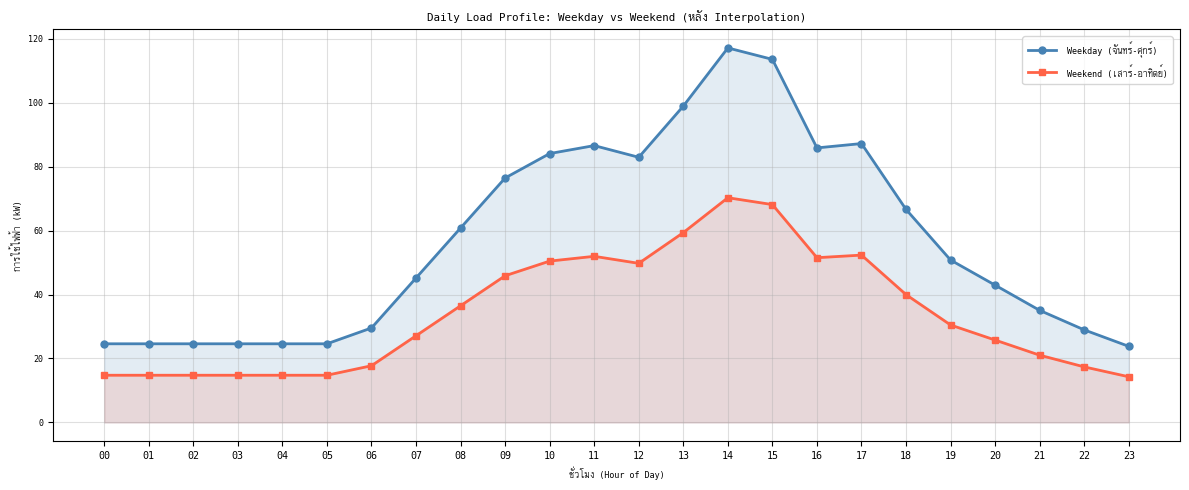

In [55]:
# แปลง Series ที่มี index เป็น time object ให้กลับเป็นตัวเลขชั่วโมง (0-23) เพื่อพล็อตกราฟ
hours = list(range(24))

fig, ax = plt.subplots(figsize=(12, 5))

# พล็อตเส้น Weekday
ax.plot(hours, hourly_weekday.values, 
        marker='o', markersize=5, linewidth=2,
        color='steelblue', label='Weekday (จันทร์-ศุกร์)')

# พล็อตเส้น Weekend
ax.plot(hours, hourly_weekend.values,
        marker='s', markersize=5, linewidth=2,
        color='tomato', label='Weekend (เสาร์-อาทิตย์)')

# ถมพื้นที่ใต้เส้นกราฟให้เห็นภาพง่ายขึ้น
ax.fill_between(hours, hourly_weekday.values, alpha=0.15, color='steelblue')
ax.fill_between(hours, hourly_weekend.values, alpha=0.15, color='tomato')

ax.set_title('Daily Load Profile: Weekday vs Weekend (หลัง Interpolation)', fontsize=13)
ax.set_xlabel('ชั่วโมง (Hour of Day)')
ax.set_ylabel('การใช้ไฟฟ้า (kW)')
ax.set_xticks(hours)
# ax.set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45, ha='right', fontsize=8)
ax.set_xticklabels([f'{h:02d}' for h in hours], rotation=0, ha='center', fontsize=12)

ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ส่วนที่ 3: สร้างฐานข้อมูล 1 ปี (Yearly Generation)

In [56]:
# สร้างวันที่ทั้งหมด 1 ปี
# บังคับใช้ปี 2023 (ปีปกติ) เพื่อให้ได้ข้อมูล 365 วัน (8760 ชั่วโมงเป๊ะ) ตามซอฟต์แวร์ปลายทางต้องการ
year_to_simulate = 2023
yearly_index = pd.date_range(start=f'{year_to_simulate}-01-01 00:00', 
                             end=f'{year_to_simulate}-12-31 23:00', 
                             freq='h')

df_year = pd.DataFrame(index=yearly_index)

# เช็คว่าแต่ละวันเป็นวันหยุดหรือไม่ (0=จันทร์, 1=อังคาร, ..., 4=ศุกร์, 5=เสาร์, 6=อาทิตย์)
df_year['is_weekend'] = df_year.index.dayofweek >= 5

# ดึงเฉพาะเวลาออกมาเพื่อใช้จับคู่
df_year['time_only'] = df_year.index.time

# ใส่ค่า Load Profile ขั้นต้นลงไปในแต่ละชั่วโมง
# np.where เปรียบเทียบเหมือน IF-ELSE: ถ้าเป็นวันหยุด ให้ใช้ข้อมูลหยุด ถ้าไม่ใช่ให้ใช้วันทำงาน
df_year['Raw_Load_kW'] = np.where(
    df_year['is_weekend'],
    df_year['time_only'].map(hourly_weekend),
    df_year['time_only'].map(hourly_weekday)
)

print(f"สร้างข้อมูลสำเร็จ จำนวนทั้งหมด: {len(df_year)} ชั่วโมง")

สร้างข้อมูลสำเร็จ จำนวนทั้งหมด: 8760 ชั่วโมง


C:\Users\DadDesk\AppData\Local\Temp\ipykernel_28400\528060249.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  yearly_index = pd.date_range(start=f'{year_to_simulate}-01-01 00:00',


# ส่วนที่ 4: ปรับสัดส่วนตามบิลรายเดือน (Monthly Scaling)

In [57]:
# ดึงเลขเดือนออกมา (1-12)
df_year['Month'] = df_year.index.month

# คำนวณยอดใช้ไฟดิบรายเดือน (พื้นที่ใต้กราฟ)
# สมมติว่าดึงกระแสไฟคงที่ใน 1 ชั่วโมง ค่า kW จะเท่ากับ kWh เลย
monthly_raw_sum = df_year.groupby('Month')['Raw_Load_kW'].sum()

# นำเป้าหมายที่ต้องการมาเทียบใน DataFrame
df_year['Target_Total'] = df_year['Month'].map(monthly_targets)

# คำนวณ Scaling Factor ของแต่ละเดือน
df_year['Scaling_Factor'] = df_year['Target_Total'] / df_year['Month'].map(monthly_raw_sum)

# นำ Scaling Factor ไปคูณกลับเพื่อปรับสัดส่วนข้อมูลทุกชั่วโมง
df_year['Adjusted_Load_kWh'] = df_year['Raw_Load_kW'] * df_year['Scaling_Factor']

# ตรวจสอบความถูกต้อง ว่าผลรวมใหม่ ตรงกับที่เราป้อนไว้ใน monthly_targets หรือไม่
validation = df_year.groupby('Month')['Adjusted_Load_kWh'].sum().round(2)
print("ผลรวมการใช้ไฟรายเดือน (ตรวจคำตอบ):")
print(validation)

ผลรวมการใช้ไฟรายเดือน (ตรวจคำตอบ):
Month
1     26000.0
2     27000.0
3     28000.0
4     29000.0
5     28000.0
6     27000.0
7     27000.0
8     27000.0
9     26000.0
10    27000.0
11    19000.0
12    19000.0
Name: Adjusted_Load_kWh, dtype: float64


# ส่วนที่ 5: พล็อตกราฟดูพฤติกรรมการใช้ไฟ

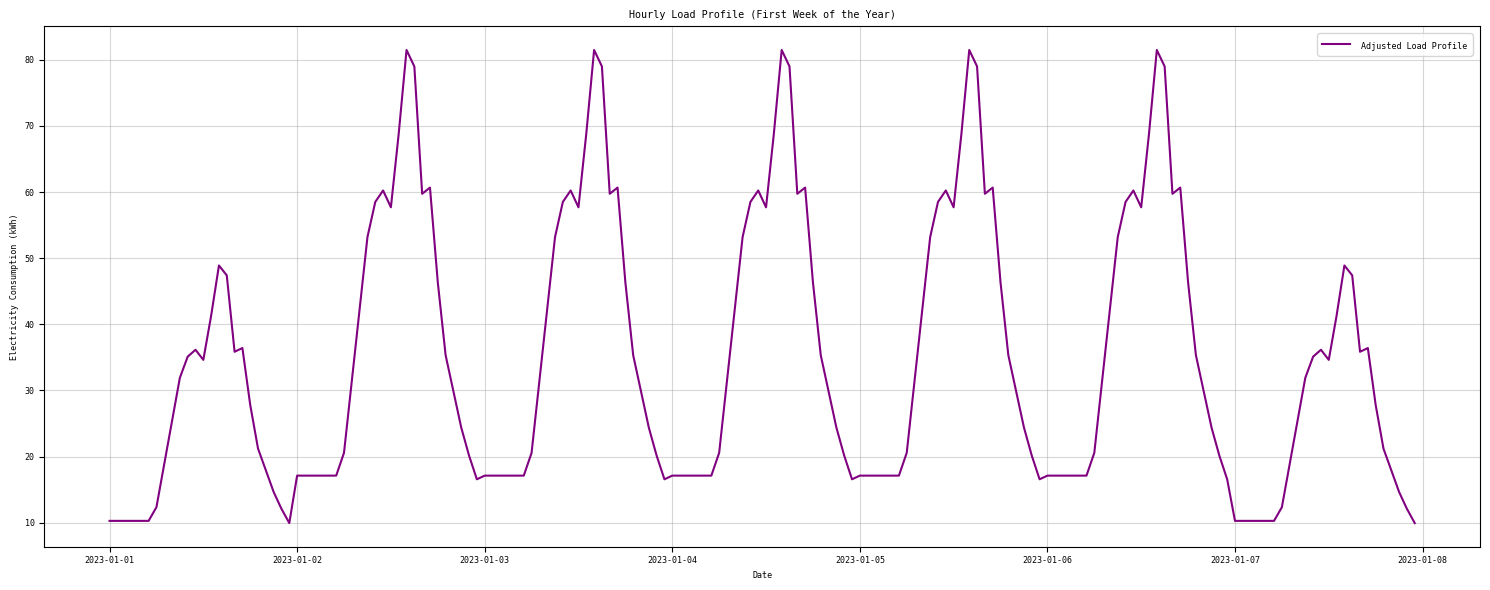

In [58]:
plt.figure(figsize=(15, 6))

# พล็อตกราฟเฉพาะสัปดาห์แรกของปี (168 ชั่วโมง) เพื่อให้เห็นความแตกต่างของวันธรรมดากับวันเสาร์อาทิตย์
plt.plot(df_year.index[:168], df_year['Adjusted_Load_kWh'][:168], label='Adjusted Load Profile', color='purple')

plt.title('Hourly Load Profile (First Week of the Year)')
plt.xlabel('Date')
plt.ylabel('Electricity Consumption (kWh)')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ส่วนที่ 6: Export ข้อมูล 8760 ชั่วโมงออกเป็นไฟล์ CSV

In [59]:
output_file = 'load_profile_8760.csv'

# ดึงเฉพาะคอลัมน์ Adjusted_Load_kWh และปัดทศนิยม 4 ตำแหน่ง
df_export = df_year['Adjusted_Load_kWh'].round(4)

# บันทึกไฟล์:
#   index=False  → ไม่เอาคอลัมน์วันเวลา
#   header=False → ไม่มี header
df_export.to_csv(output_file, index=False, header=False)

print(f"Export สำเร็จ! บันทึกไปที่: {output_file}")
print(f"จำนวนแถว: {len(df_export)} แถว")
print(f"\nตัวอย่าง 5 แถวแรก:")
print(df_export.head().to_string())
print(f"\nตัวอย่าง 5 แถวสุดท้าย:")
print(df_export.tail().to_string())

Export สำเร็จ! บันทึกไปที่: load_profile_8760.csv
จำนวนแถว: 8760 แถว

ตัวอย่าง 5 แถวแรก:
2023-01-01 00:00:00    10.2643
2023-01-01 01:00:00    10.2643
2023-01-01 02:00:00    10.2643
2023-01-01 03:00:00    10.2643
2023-01-01 04:00:00    10.2643
Freq: h

ตัวอย่าง 5 แถวสุดท้าย:
2023-12-31 19:00:00    15.7202
2023-12-31 20:00:00    13.2881
2023-12-31 21:00:00    10.8485
2023-12-31 22:00:00     8.9587
2023-12-31 23:00:00     7.3650
Freq: h


# ส่วนที่ 7: จำลองการผลิตไฟฟ้าจากโซลาร์เซลล์ (PV Simulation)
จำลองการผลิตไฟฟ้า 8760 ชั่วโมงด้วย pvlib โดยใช้ข้อมูลสภาพอากาศ TMY ของ กทม.

In [60]:
lat, lon = 13.75, 100.51  # กรุงเทพมหานคร

# 1. ดึงข้อมูลสภาพอากาศ TMY (Typical Meteorological Year) จาก PVGIS
print("กำลังดึงข้อมูลสภาพอากาศ TMY ของกรุงเทพมหานคร จากฐานข้อมูล PVGIS...")
tmy_data = iotools.get_pvgis_tmy(lat, lon, map_variables=True)[0]

# 2. ปรับเวลาให้เป็น Local Time (Asia/Bangkok) และเรียงข้อมูลให้เริ่มจากวันที่ 1 ม.ค. 00:00
tmy_data.index = tmy_data.index.tz_convert('Asia/Bangkok')
tmy_data['month'] = tmy_data.index.month
tmy_data['day'] = tmy_data.index.day
tmy_data['hour'] = tmy_data.index.hour
tmy_data = tmy_data.sort_values(['month', 'day', 'hour'])

# เปลี่ยน index กลับมาเป็นปี 2023 ตามที่เราใช้ใน Load Profile
tmy_data.index = pd.date_range(start='2023-01-01 00:00', end='2023-12-31 23:00', freq='h', tz='Asia/Bangkok')

# 3. ตั้งค่าระบบ PV System (100 kWac, 120 kWdc)
location = Location(latitude=lat, longitude=lon, tz='Asia/Bangkok')
system = PVSystem(
    surface_tilt=15,             # มุมเอียง 15 องศา (เหมาะกับไทย)
    surface_azimuth=180,         # หันหน้าทิศใต้ (180 องศา)
    module_parameters={'pdc0': 120000, 'gamma_pdc': -0.0035}, # ขนาด DC 120kW, Temp. coeff -0.35%/C
    inverter_parameters={'pdc0': 100000 / 0.96, 'pac0': 100000, 'eta_inv_nom': 0.96}, # Inverter 100kWac, Efficiency 96%
    temperature_model_parameters=TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
)

# ใช้ ModelChain กับโมเดล PVWatts ซึ่งเป็นมาตรฐานสากลที่ตั้งค่า loss ต่างๆ ไว้เสร็จสรรพ
mc = ModelChain(system, location, 
                aoi_model='physical', spectral_model='no_loss', 
                dc_model='pvwatts', ac_model='pvwatts', losses_model='pvwatts')

print("กำลังคำนวณการผลิตไฟฟ้ารายชั่วโมง...")
mc.run_model(tmy_data)
pv_generation_ac = mc.results.ac  # พลังงานฝั่ง AC (วัตต์)
pv_generation_kw = pv_generation_ac / 1000  # แปลงเป็นกิโลวัตต์ (kW)

# เติมค่าที่น้อยกว่า 0 ให้เป็น 0 (เวลากลางคืน inverter อาจมี standby loss เล็กน้อยจนค่าติดลบ)
pv_generation_kw = pv_generation_kw.clip(lower=0)

# นำไปใส่ใน DataFrame หลัก
# ต้องทำให้ index ไม่มี Timezone (tz-naive) เพื่อให้ตรงกับ index ของ df_year เดิม
pv_generation_kw.index = df_year.index
df_year['PV_Generation_kW'] = pv_generation_kw

print(f"\n✅ การจำลอง PV เสร็จสมบูรณ์!")
print(f"กำลังการผลิตรวมทั้งปี: {df_year['PV_Generation_kW'].sum():,.2f} kWh/ปี")
print(f"กำลังการผลิตสูงสุด (Max Power): {df_year['PV_Generation_kW'].max():.2f} kW")

กำลังดึงข้อมูลสภาพอากาศ TMY ของกรุงเทพมหานคร จากฐานข้อมูล PVGIS...
กำลังคำนวณการผลิตไฟฟ้ารายชั่วโมง...

✅ การจำลอง PV เสร็จสมบูรณ์!
กำลังการผลิตรวมทั้งปี: 168,836.38 kWh/ปี
กำลังการผลิตสูงสุด (Max Power): 90.68 kW


C:\Users\DadDesk\AppData\Local\Temp\ipykernel_28400\1286387073.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tmy_data.index = pd.date_range(start='2023-01-01 00:00', end='2023-12-31 23:00', freq='1H', tz='Asia/Bangkok')


# ส่วนที่ 8: คำนวณ Net Load (Load - PV) และพล็อตกราฟเปรียบเทียบ

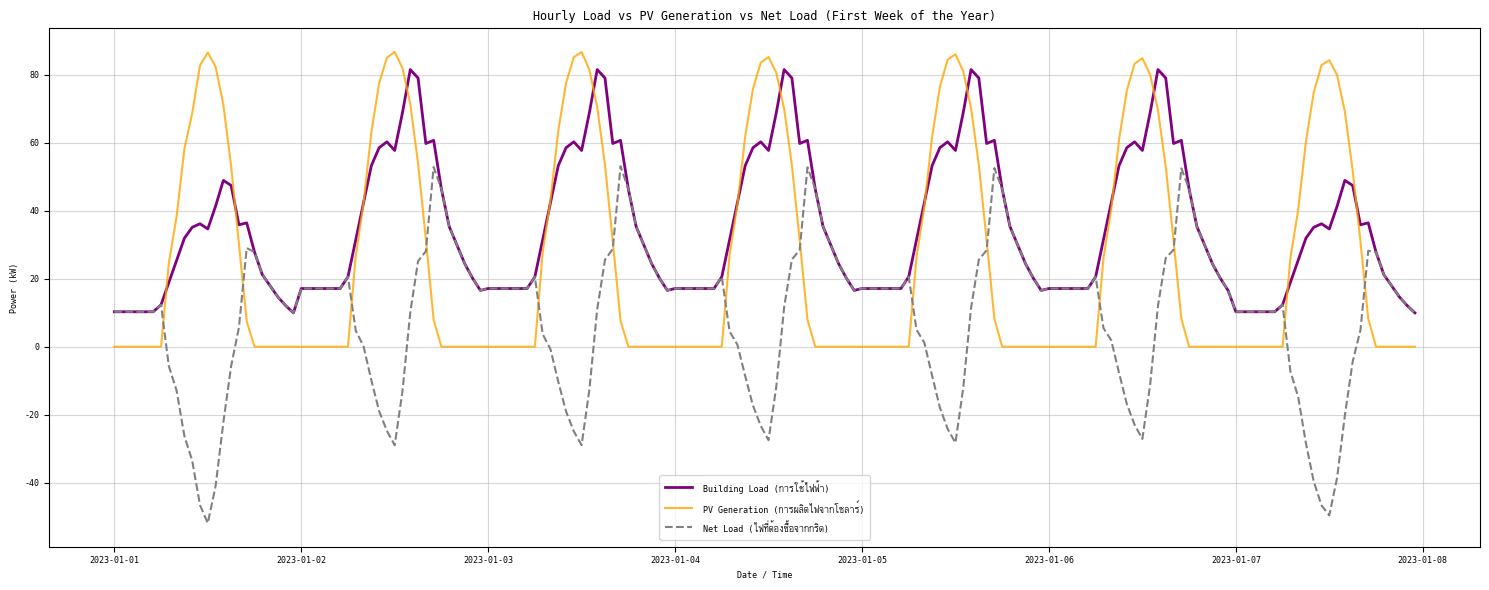

In [61]:
# คำนวณ Net Load (การใช้ไฟสุทธิ)
# ถ้า PV ผลิตได้มากกว่าที่ใช้ (Load) ค่า Net Load จะติดลบ แปลว่ามีไฟ Export ไหลกลับกริด
df_year['Net_Load_kW'] = df_year['Adjusted_Load_kWh'] - df_year['PV_Generation_kW']

# แสดงกราฟสัปดาห์แรกของปี
plt.figure(figsize=(15, 6))
plt.plot(df_year.index[:168], df_year['Adjusted_Load_kWh'][:168], label='Building Load (การใช้ไฟฟ้า)', color='purple', linewidth=2)
plt.plot(df_year.index[:168], df_year['PV_Generation_kW'][:168], label='PV Generation (การผลิตไฟจากโซลาร์)', color='orange', alpha=0.8)
plt.plot(df_year.index[:168], df_year['Net_Load_kW'][:168], label='Net Load (ไฟที่ต้องซื้อจากกริด)', color='gray', linestyle='--')

plt.title('Hourly Load vs PV Generation vs Net Load (First Week of the Year)', fontsize=14)
plt.xlabel('Date / Time')
plt.ylabel('Power (kW)')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# Export ข้อมูลใหม่ทั้งหมด (Load, PV, Net Load) รวมไว้ในไฟล์เดียว เพื่อนำไปวิเคราะห์ต่อ
output_file_all = 'combined_profile_8760.csv'
df_export_all = df_year[['Adjusted_Load_kWh', 'PV_Generation_kW', 'Net_Load_kW']].round(4)
df_export_all.to_csv(output_file_all, index=False)
print(f"\nExport ข้อมูลรวมสำเร็จ! บันทึกไปที่: {output_file_all}")


Export ข้อมูลรวมสำเร็จ! บันทึกไปที่: combined_profile_8760.csv
